### Build a Basic Chat Bot with langhGraph (GRAPH API)

In [9]:
from typing import Annotated
from typing_extensions import TypedDict 
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [10]:
class State(TypedDict):
    messages: Annotated[list, add_messages]
    
graph_builder = StateGraph(State)

In [11]:
graph_builder

In [12]:
import os
from dotenv import load_dotenv
load_dotenv()


True

In [13]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0.9)

In [14]:
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x11e39a460>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x11e3bdaf0>, model_name='openai/gpt-oss-120b', temperature=0.9, model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [ ]:
llm = init_chat_model("groq:openai/gpt-oss-120b")
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x11e547100>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x11e5476d0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [16]:
## Node functionality
def chatbot(state:State):
    return {
        "messages": [llm.invoke(state["messages"])]
        }

In [17]:
graph_builder = StateGraph(State)

## adding node
graph_builder.add_node("llmchatbot", chatbot)

## adding edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

## compile the graph
graph = graph_builder.compile()



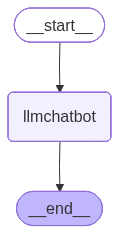

In [18]:
## Visualize the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Error occurred while visualizing the graph: {e}")

In [19]:
response = graph.invoke({"messages":"Hi there!"})
response

{'messages': [HumanMessage(content='Hi there!', additional_kwargs={}, response_metadata={}, id='c2da834c-e518-4306-b139-5aafdeb0b924'),
  AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "Hi there!" A greeting. We respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 74, 'total_tokens': 107, 'completion_time': 0.069027513, 'completion_tokens_details': {'reasoning_tokens': 15}, 'prompt_time': 0.002740564, 'prompt_tokens_details': None, 'queue_time': 0.051170195, 'total_time': 0.071768077}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_d81b3304b3', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--019dfb0f-9750-7612-a1b8-f2ad36ea5182-0', usage_metadata={'input_tokens': 74, 'output_tokens': 33, 'total_tokens': 107})]}

In [20]:
response["messages"]

[HumanMessage(content='Hi there!', additional_kwargs={}, response_metadata={}, id='c2da834c-e518-4306-b139-5aafdeb0b924'),
 AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "Hi there!" A greeting. We respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 74, 'total_tokens': 107, 'completion_time': 0.069027513, 'completion_tokens_details': {'reasoning_tokens': 15}, 'prompt_time': 0.002740564, 'prompt_tokens_details': None, 'queue_time': 0.051170195, 'total_time': 0.071768077}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_d81b3304b3', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--019dfb0f-9750-7612-a1b8-f2ad36ea5182-0', usage_metadata={'input_tokens': 74, 'output_tokens': 33, 'total_tokens': 107})]

In [21]:
## retrieve the last message or content

response["messages"][-1].content

'Hello! How can I help you today?'

In [22]:
for event in graph.stream({"messages":"Hi there!"}):
    print(event)

{'llmchatbot': {'messages': [AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "Hi there!" A greeting. We should respond friendly. No special instructions. Should be short and polite.'}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 74, 'total_tokens': 118, 'completion_time': 0.096479995, 'completion_tokens_details': {'reasoning_tokens': 26}, 'prompt_time': 0.003088309, 'prompt_tokens_details': None, 'queue_time': 0.050279651, 'total_time': 0.099568304}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_626f3fc5e0', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--019dfb0f-986c-7f02-a1dc-8da1622ce988-0', usage_metadata={'input_tokens': 74, 'output_tokens': 44, 'total_tokens': 118})]}}


In [23]:
for event in graph.stream({"messages":"Hi there!"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello! How can I help you today?


### Chatbot with Tools

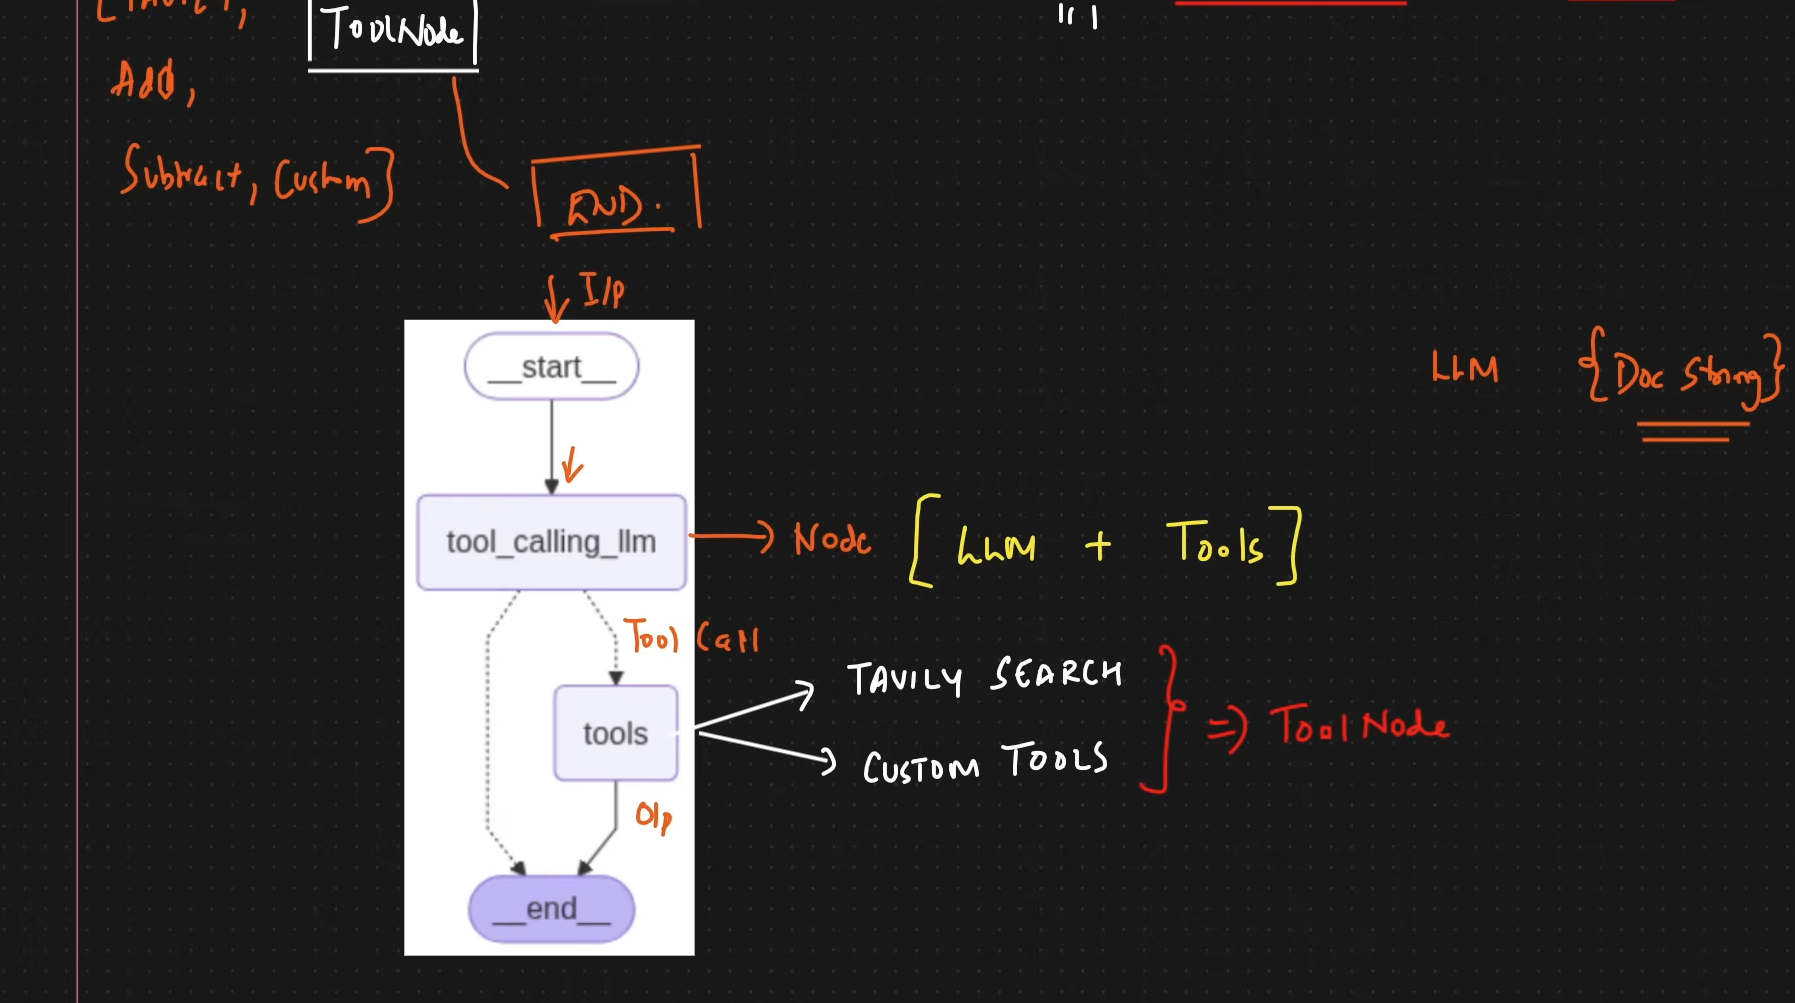

In [24]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=1)
tool.invoke("What is the capital of France?")

{'query': 'What is the capital of France?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.worldatlas.com/articles/what-is-the-capital-of-france.html',
   'title': 'What is the Capital of France? - World Atlas',
   'content': 'Paris is the capital city of France. The city has an approximate area of 41 square miles with a population of 2,206,488 people as of 2018. Contrary to popular belief, the name of the city did not come from the Paris in Greek myths. Instead, the name Paris is derived from the city’s initial inhabitants who were part of the Celtic Parisii tribe. Located in the north of Central France, the city is relatively flat with the highest point being 427 feet (which is Montmartre) above sea level while the lowest point is 115 feet above the sea level. With a GDP of approximately $850 billion, Paris is the country’s leader for economic activities. Tourists are attracted to Paris because of the rich history the city has includin

In [44]:
## custom function 

def multiply(a:int, b:int)-> int:
    """Multiply a and b
    
    Args: 
        a (int) : first int
        b (int) : second int


    Returns:
        int: output int    
    """
    return a*b

In [46]:
tools = [tool, multiply]


In [47]:
llm_with_tool =  llm.bind_tools(tools)

In [48]:
llm_with_tool

RunnableBinding(bound=ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x11e547100>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x11e5476d0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'Search query to look up', 'type': 'string'}, 'include_domains': {'anyOf': [{'items': {'type': 'string'}, 'type': 'array'}, {'type': 'null'}], 'default':

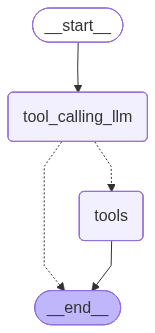

In [49]:
## Stategraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image, display



## Node definition
def tool_calling_llm(state: State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Graph

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## add edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
    # {
    #     "tools": "tools",
    #     "continue": "tool_calling_llm"
    # }
)

builder.add_edge("tools", END)

## compile the graph
graph = builder.compile()

## Visualize the graph
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Error occurred while visualizing the graph: {e}")



In [35]:
response = graph.invoke({"messages":"What is the recent AI news?"})

In [36]:
response['messages'][-1].content

'{"query": "latest AI news week", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.forbes.com/sites/davidphelan/2026/05/01/samsung-one-ui-85-update-missing-why-millions-of-galaxy-users-are-still-waiting-today/", "title": "Samsung One UI 8.5 Update Missing: Why Galaxy Users Are Still Waiting Today - Forbes", "score": 0.96691406, "published_date": "Sat, 02 May 2026 08:00:00 GMT", "content": "“Beta testers also praise the software’s fluidity and stability, as compared to the One UI 8.0 software,” Sammyfans has said.\\n\\n1/1 Skip Ad Continue watching after the adImage 12: Loading PodsVisit Advertiser websiteGO TO PAGE\\n\\nThe Prompt: Get the week’s biggest AI news on the buzziest companies and boldest breakthroughs, in your inbox.\\n\\nEmail Address \\n\\n Sign Up \\n\\nBy signing up, you agree to receive this newsletter, other updates about Forbes and its affiliates’ offerings, our Terms of Service (including resolving disputes on an individual

In [37]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_5e24b416-b25b-47e0-8292-3afd9f8d7b4e)
 Call ID: fc_5e24b416-b25b-47e0-8292-3afd9f8d7b4e
  Args:
    query: latest AI news week
    search_depth: advanced
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news week", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.forbes.com/sites/davidphelan/2026/05/01/samsung-one-ui-85-update-missing-why-millions-of-galaxy-users-are-still-waiting-today/", "title": "Samsung One UI 8.5 Update Missing: Why Galaxy Users Are Still Waiting Today - Forbes", "score": 0.96691406, "published_date": "Sat, 02 May 2026 08:00:00 GMT", "content": "“Beta testers also praise the software’s fluidity

In [50]:
response = graph.invoke({"messages": "can you multiply 5 and 6?"})
for m in response['messages']:
    m.pretty_print()


================================ Human Message =================================

can you multiply 5 and 6?
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_5ffa5d72-9ecd-43f3-8693-ae6ccc463cf9)
 Call ID: fc_5ffa5d72-9ecd-43f3-8693-ae6ccc463cf9
  Args:
    a: 5
    b: 6
================================= Tool Message =================================
Name: multiply

30


## ReAct Architecture


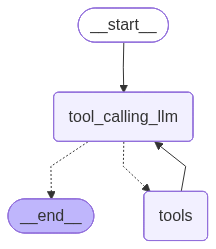

In [51]:
## Stategraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image, display



## Node definition
def tool_calling_llm(state: State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Graph

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## add edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
    # {
    #     "tools": "tools",
    #     "continue": "tool_calling_llm"
    # }
)

builder.add_edge("tools", "tool_calling_llm")

## compile the graph
graph = builder.compile()

## Visualize the graph
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Error occurred while visualizing the graph: {e}")



In [53]:
response = graph.invoke({"messages": "Give me the recent ai news and then multiply 5 by 6?"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 6?
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_fd395e44-979c-49b6-9746-803dbc7b58e2)
 Call ID: fc_fd395e44-979c-49b6-9746-803dbc7b58e2
  Args:
    a: 5
    b: 6
================================= Tool Message =================================
Name: multiply

30
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_f7687478-56f6-4d1c-9736-54fa8df5152c)
 Call ID: fc_f7687478-56f6-4d1c-9736-54fa8df5152c
  Args:
    query: latest AI news 2024 May 2024 artificial intelligence recent developments
    search_depth: advanced
    time_range: month
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news 2024 May 2024 artificial intelligence recent developments

### Adding Memory in Agentic Graph

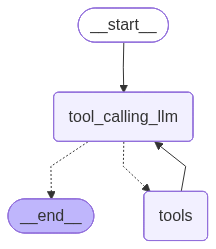

In [54]:
## Stategraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()



## Node definition
def tool_calling_llm(state: State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Graph

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## add edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
    # {
    #     "tools": "tools",
    #     "continue": "tool_calling_llm"
    # }
)

builder.add_edge("tools", "tool_calling_llm")

## compile the graph
graph = builder.compile(checkpointer=memory)

## Visualize the graph
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Error occurred while visualizing the graph: {e}")



In [56]:
config = {"configurable": {"thread_id": "1"}}

response = graph.invoke({"messages": "My name is Arnab"}, config=config)
response

{'messages': [HumanMessage(content='My name is Arnab', additional_kwargs={}, response_metadata={}, id='17aeb89a-9888-4995-9fb6-624920367ef5'),
  AIMessage(content='Nice to meet you, Arnab! How can I assist you today?', additional_kwargs={'reasoning_content': 'The user says "My name is Arnab". Likely they are introducing themselves. We can respond politely, perhaps ask how we can help. No need to use tools.'}, response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 349, 'total_tokens': 409, 'completion_time': 0.129721057, 'completion_tokens_details': {'reasoning_tokens': 36}, 'prompt_time': 0.005933573, 'prompt_tokens_details': {'cached_tokens': 256}, 'queue_time': 0.052021893, 'total_time': 0.13565463}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_8a618bed98', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--019dfb53-a33d-7621-88c0-3aca1149c0a3-0', usage_metadata={'input_tokens': 349, 'output_tokens': 60, 'total_to

In [57]:
response['messages'][-1].content

'Nice to meet you, Arnab! How can I assist you today?'

In [58]:
response = graph.invoke({"messages": "what is my name"}, config=config)
response['messages'][-1].content

'Your name is Arnab.'

### Streaming

In [59]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [60]:
def superbot(state:State):
    return {"messages": [llm.invoke(state["messages"])]}

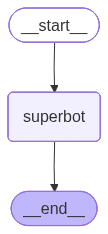

In [61]:

graph = StateGraph(State)

## node

graph.add_node("superbot",superbot)

## edges

graph.add_edge(START, "superbot")
graph.add_edge("superbot", END)

graph_builder = graph.compile(checkpointer=memory)

# display

from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [62]:
# invocation

config = {"configurable":{"thread_id":"1"}}
graph_builder.invoke({'messages': "Hi, My name is Arnab"}, config)

{'messages': [HumanMessage(content='Hi, My name is Arnab', additional_kwargs={}, response_metadata={}, id='91b3e0f4-61f0-4955-8947-673f0220938e'),
  AIMessage(content='Hello Arnab! Nice to meet you. How can I assist you today?', additional_kwargs={'reasoning_content': 'The user says "Hi, My name is Arnab". The system message says we must follow policies. There\'s no disallowed content. We should respond politely, perhaps ask how we can help.'}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 78, 'total_tokens': 143, 'completion_time': 0.136403599, 'completion_tokens_details': {'reasoning_tokens': 40}, 'prompt_time': 0.009310656, 'prompt_tokens_details': None, 'queue_time': 0.06053641, 'total_time': 0.145714255}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e10890e4b9', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--019dffbf-2e38-7d23-9325-f19aabf5654e-0', usage_metadata={'input_tokens': 78, 'output_tokens

### Streaming
Methods: .stream() and astream()

These methods are sync and async methods for streaming back results.
Additional parameters in streaming modes for graph state

values : This streams the full state of the graph after each node is called.
updates : This streams updates to the state of the graph after each node is called.

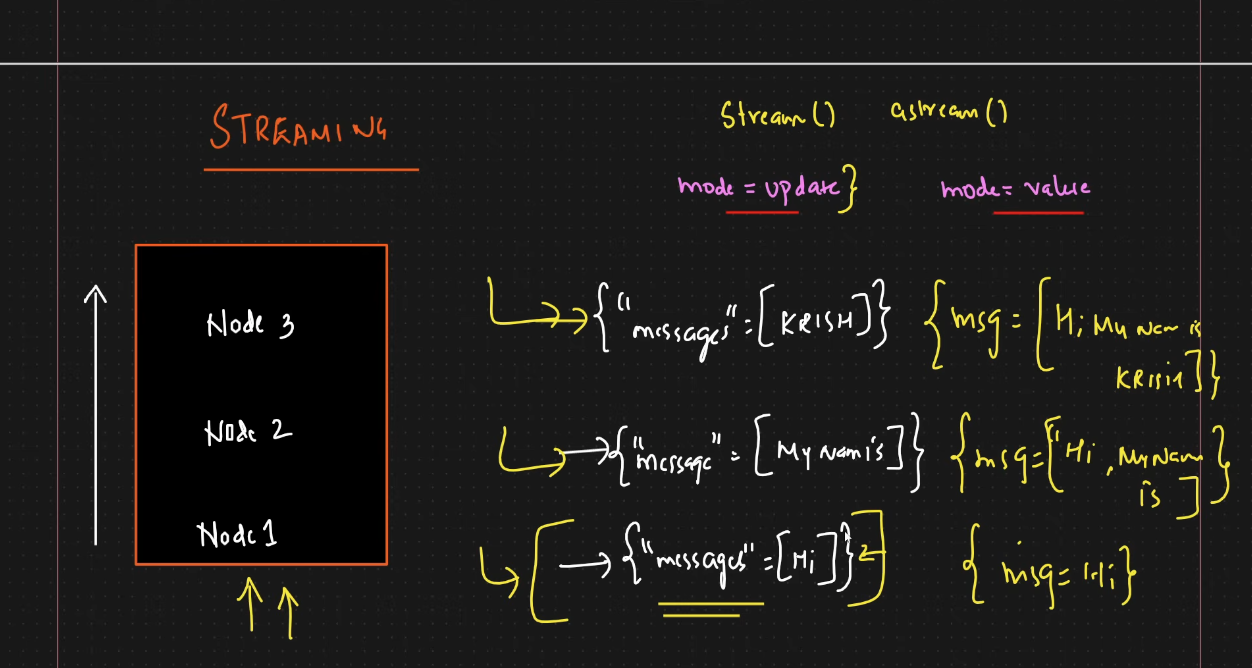

In [63]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content='Hello Krish! 👋 Nice to meet you. It’s great to hear you’re a cricket fan. Do you have a favorite team or player you follow? Are you more into Test matches, ODIs, T20s, or maybe all of the action? Let me know—happy to chat about the game!', additional_kwargs={'reasoning_content': 'We need to respond. The user says "Hi, My name is Krish And I like cricket". We can greet, ask about cricket preferences, maybe ask about favorite team. No disallowed content. Just friendly.'}, response_metadata={'token_usage': {'completion_tokens': 119, 'prompt_tokens': 82, 'total_tokens': 201, 'completion_time': 0.249346711, 'completion_tokens_details': {'reasoning_tokens': 45}, 'prompt_time': 0.003215283, 'prompt_tokens_details': None, 'queue_time': 0.060142853, 'total_time': 0.252561994}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_4a19b1544c', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--019dffc4-8ee7-750

In [64]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='90fb96ad-ef56-4ac4-8ad5-a41939abf471'), AIMessage(content='Hello Krish! 👋 Nice to meet you. It’s great to hear you’re a cricket fan. Do you have a favorite team or player you follow? Are you more into Test matches, ODIs, T20s, or maybe all of the action? Let me know—happy to chat about the game!', additional_kwargs={'reasoning_content': 'We need to respond. The user says "Hi, My name is Krish And I like cricket". We can greet, ask about cricket preferences, maybe ask about favorite team. No disallowed content. Just friendly.'}, response_metadata={'token_usage': {'completion_tokens': 119, 'prompt_tokens': 82, 'total_tokens': 201, 'completion_time': 0.249346711, 'completion_tokens_details': {'reasoning_tokens': 45}, 'prompt_time': 0.003215283, 'prompt_tokens_details': None, 'queue_time': 0.060142853, 'total_time': 0.252561994}, 'model_name': 'openai/gpt-oss-120b', 

In [65]:
# Create a thread
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content='Hi Krish! 👋 Great to meet you. Cricket is such an exciting sport—do you have a favorite team or player? Are you more into the fast‑bowling action, the batting fireworks, or maybe the strategic side of the game? Let me know, and we can chat all things cricket!', additional_kwargs={'reasoning_content': 'The user says: "Hi, My name is Krish And I like cricket". We need to respond appropriately. No policy violation. Just greet, maybe ask about cricket preferences, etc. Should be friendly.'}, response_metadata={'token_usage': {'completion_tokens': 115, 'prompt_tokens': 82, 'total_tokens': 197, 'completion_time': 0.238559619, 'completion_tokens_details': {'reasoning_tokens': 43}, 'prompt_time': 0.003685009, 'prompt_tokens_details': None, 'queue_time': 0.065886171, 'total_time': 0.242244628}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_45f51928b5', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run-

In [66]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='b50faf36-5d4c-49e7-bd46-d6d593531890'), AIMessage(content='Hi Krish! 👋 Great to meet you. Cricket is such an exciting sport—do you have a favorite team or player? Are you more into the fast‑bowling action, the batting fireworks, or maybe the strategic side of the game? Let me know, and we can chat all things cricket!', additional_kwargs={'reasoning_content': 'The user says: "Hi, My name is Krish And I like cricket". We need to respond appropriately. No policy violation. Just greet, maybe ask about cricket preferences, etc. Should be friendly.'}, response_metadata={'token_usage': {'completion_tokens': 115, 'prompt_tokens': 82, 'total_tokens': 197, 'completion_time': 0.238559619, 'completion_tokens_details': {'reasoning_tokens': 43}, 'prompt_time': 0.003685009, 'prompt_tokens_details': None, 'queue_time': 0.065886171, 'total_time': 0.242244628}, 'model_name': 'open

In [71]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Krish and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019dffcc-1263-7731-b35b-b1a718c6f1da', 'metadata': {'thread_id': '5'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='1816bcbd-04a5-4aaf-8d90-998e230748fa'), AIMessage(content="Hello Krish! 👋 Nice to meet you.  \n\nCricket is such an exciting sport—whether you’re into the fast‑paced action of T20, the strategic depth of Test cricket, or anything in between. Do you have a favorite team or player? Or maybe a memorable match that’s stuck with you? I'd love to hear more about what you enjoy most about cricket!", additional_kwargs={'reasoning_content': 'The user says "Hi, My name is Krish And I like cricket". Probably they are just greeting and sharing info. We respond politely, perhaps ask about 